<h1 align="center"> </h1>

<h2 align="center">Análise Exploratória </h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path


REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'gtfs'

In [2]:
arquivos_gtfs = [
    'agency',
    'calendar',
    'fare_attributes',
    'fare_rules',
    'frequencies',
    'routes',
    'shapes',
    'stop_times',
    'stops',
    'trips'
]

gtfs = {}
for arquivo in arquivos_gtfs:
    caminho = DATA_PATH / f'{arquivo}.txt'
    gtfs[arquivo] = pd.read_csv(caminho)
    n_linhas, n_colunas = gtfs[arquivo].shape
    print(f" {arquivo:<20} {n_linhas:>10,} linhas | {n_colunas} colunas")

 agency                        1 linhas | 5 colunas
 calendar                      6 linhas | 10 colunas
 fare_attributes               6 linhas | 6 colunas
 fare_rules                5,379 linhas | 5 colunas
 frequencies              40,146 linhas | 4 colunas
 routes                    1,348 linhas | 7 colunas
 shapes                1,134,502 linhas | 5 colunas
 stop_times               98,434 linhas | 5 colunas
 stops                    22,103 linhas | 5 colunas
 trips                     2,254 linhas | 6 colunas


### `stops.txt`

In [3]:
print(gtfs['stops'].info())

<class 'pandas.DataFrame'>
RangeIndex: 22103 entries, 0 to 22102
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stop_id    22103 non-null  int64  
 1   stop_name  22103 non-null  str    
 2   stop_desc  20684 non-null  str    
 3   stop_lat   22103 non-null  float64
 4   stop_lon   22103 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 2.2 MB
None


In [4]:
print(gtfs['stops'].head())

   stop_id      stop_name stop_desc   stop_lat   stop_lon
0    18848       Clínicas       NaN -23.554022 -46.671108
1    18849  Vila Madalena       NaN -23.546498 -46.691141
2    18850     Consolação       NaN -23.558094 -46.660205
3    18851      Conceição       NaN -23.635039 -46.641239
4    18852      Jabaquara       NaN -23.646033 -46.641028


In [5]:
# valores nulos
print(gtfs['stops'].isnull().sum())

stop_id         0
stop_name       0
stop_desc    1419
stop_lat        0
stop_lon        0
dtype: int64


In [6]:
stops = gtfs['stops']
print(f'Latitude:  {stops.stop_lat.min():.4f} (sul) a {stops.stop_lat.max():.4f} (norte)')
print(f'Longitude: {stops.stop_lon.min():.4f} (oeste) a {stops.stop_lon.max():.4f} (leste)')

Latitude:  -23.9111 (sul) a -23.1956 (norte)
Longitude: -46.9839 (oeste) a -46.1849 (leste)


In [7]:
import geopandas as gpd

municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# colunas do shapefile
print("Colunas:", list(municipios.columns))
print()

Colunas: ['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']



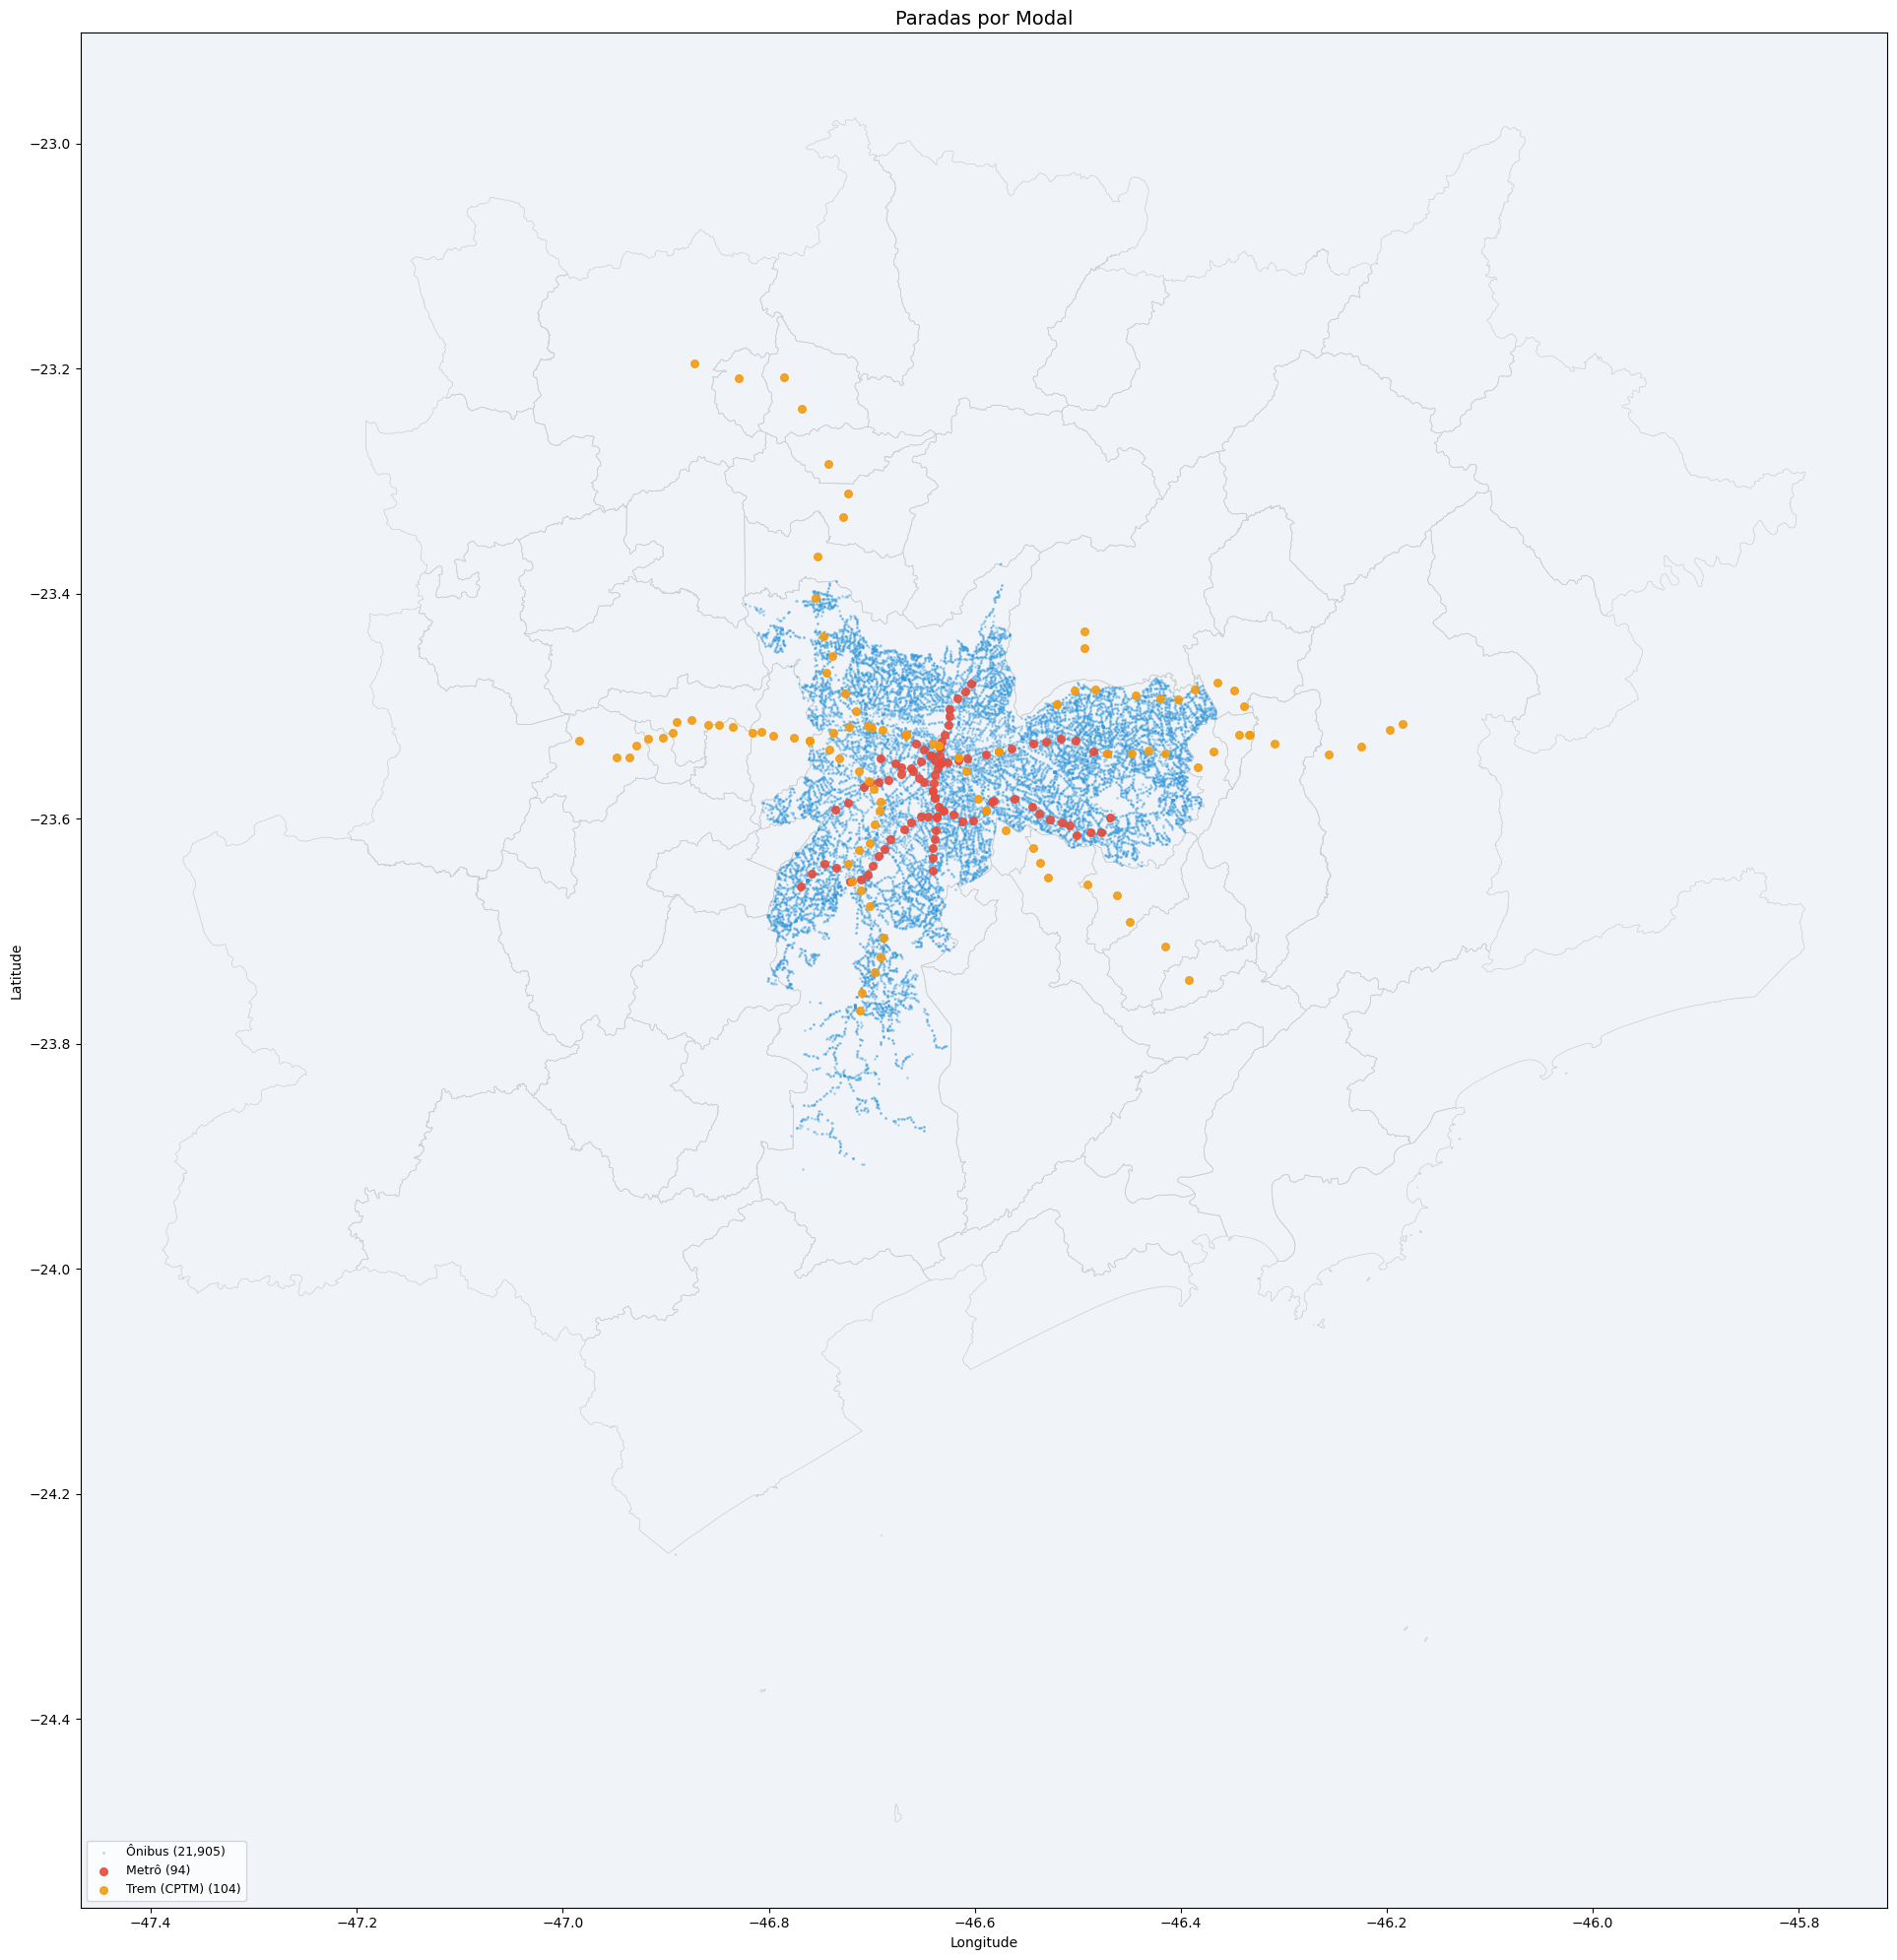

In [8]:
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']


# Combinações únicas de (stop_id, trip_id) do stop_times
# drop_duplicates() remove repetições — só precisamos saber QUAIS trips passam em QUAIS paradas, não quantas vezes
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# Adicionar route_id (de trips.txt)
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# Adicionar route_type (de routes.txt)
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# Para cada parada, pegar o route_type predominante
# Uma parada pode ter ônibus E metrô passando. Usamos first() como simplificação.
# groupby('stop_id') agrupa todas as linhas com mesmo stop_id
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# Juntar de volta com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')

# limites municipais
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')

# Região Metropolitana de São Paulo (RMSP)
margem = 0.05
lon_min = stops_com_modal['stop_lon'].min() - margem
lon_max = stops_com_modal['stop_lon'].max() + margem
lat_min = stops_com_modal['stop_lat'].min() - margem
lat_max = stops_com_modal['stop_lat'].max() + margem

municipios_recorte = municipios.cx[lon_min:lon_max, lat_min:lat_max]


fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f0f4f8')


municipios_recorte.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#cccccc',
    linewidth=0.5,
    zorder=1
)

# Plotar paradas por cima dos limites municipais
cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,
        alpha=0.3 if route_type == 3 else 0.9,
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3
    )

ax.set_title('Paradas por Modal', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.show()

### `stop_times.txt`

In [9]:
print(gtfs['stop_times'].info())

<class 'pandas.DataFrame'>
RangeIndex: 98434 entries, 0 to 98433
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   trip_id         98434 non-null  str  
 1   arrival_time    98434 non-null  str  
 2   departure_time  98434 non-null  str  
 3   stop_id         98434 non-null  int64
 4   stop_sequence   98434 non-null  int64
dtypes: int64(2), str(3)
memory usage: 6.1 MB
None


<h2 align="center">Grafo</h2>

<h2 align="center">Vulnerabilidade</h2>

<h2 align="center">Resiliência</h2>